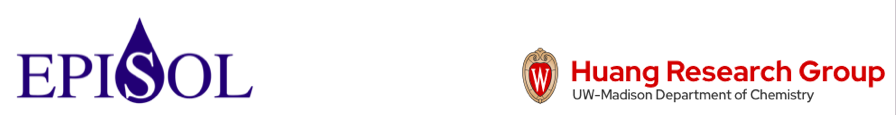

Have you ever needed a reliable way to place the initial positions of Mg²⁺ ions in RNA or DNA molecular dynamics simulations? These divalent ions play a critical role in nucleic acid structure and dynamics.

This tutorial demonstrating how to achieve this using our EPIPY package. The method is based on the 3DRISM-IDC theory, which was specifically developed to model solvation around highly negatively charged solutes such as nucleic acids.

If you use the materials in this tutorial, please cite: "A Python Tutorial for 3DRISM Solvation Calculations of Chemical and Biological Molecules", Swanson, P., Cao, S., Huang, X, https://chemrxiv.org/engage/chemrxiv/article-details/68a6903c728bf9025e6c91ed

## **Placing Magnesium in Highly Correlated Regions of RNA kink-Turn**





In [1]:
#@title ##Download and Install Episol
#@markdown ($\approx 2$min) Stable as of 07/01/25 eprism v1.2.6
%%capture
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
#%cd ../home/
%cd $HOME/
%mkdir episol
%cd episol
!wget https://github.com/EPISOLrelease/EPISOL/raw/refs/heads/main/src/fftw/fftw-3.3.8.tar.gz
!echo "+++++++++++++++++++"
!echo "downloaded fftw files"
!echo "+++++++++++++++++++"
!tar -xzf fftw-3.3.8.tar.gz
%cd fftw-3.3.8/
#!./configure --prefix=/home/fftw-3.3.8
!./configure --prefix=$HOME/episol/fftw-3.3.8
!make
!make install
%cd ../
!wget https://github.com/EPISOLrelease/EPISOL/raw/refs/heads/main/src/kernel/release.tar.gz
!echo "+++++++++++++++++++"
!echo "downloaded Episol files"
!echo "+++++++++++++++++++"
!tar -xzf release.tar.gz
%cd release/
#!./configure --with-fftw=/home/fftw-3.3.8
!./configure --with-fftw=$HOME/episol/fftw-3.3.8
!make
!make install
#%cd /content
########################### WRAPEPR
!pip install episol==0.1.2
#!python3.12 -m pip install --upgrade setuptools
import subprocess
import os
import threading
import pandas as pd
import matplotlib.pyplot as plt
from episol import epipy


In [2]:
%%capture

#@title Install some python packages for topology generation
#@markdown ($\approx$4-8min)

#@markdown This will prompt a restart in our colab session, this is necessary, just keep moving

#@markdown (if you are using the notebook offline this wont be necessary, as presumably you'll have your own forcefield to generate topologies)
########################################
#        FOR COLAB USERS ONLY          #
#---------------------------------------#
# if you are running locally you dont need
# condacolab. Just use your local conda dist
########################################
!pip install -q condacolab
import condacolab
condacolab.install()
########################################
#!conda update conda
#!conda install --yes -c conda-forge  python=3.11 numpy=1.26.4 openmm pdbfixer parmed mdanalysis py3dmol rdkit openff-toolkit
#!conda install -y -c conda-forge numpy=1.26.4 openmm=8.3.1 python={PYTHON_VERSION} pdbfixer=1.11 parmed=4.3.0 mdanalysis=2.9.0 py3dmol=2.5.2 rdkit=2025.03.5 openff-toolkit=0.17.0 libgcc
!conda install -y -c conda-forge python=3.12 numpy=1.26.4 openmm=8.3.1 pdbfixer=1.11 parmed=4.3.0 mdanalysis=2.9.0 py3dmol=2.5.2 rdkit=2025.03.5 openff-toolkit=0.17.0 torchvision pymol-open-source
!python3.12 -m pip install --upgrade setuptools
!python -m ensurepip --upgrade
#openmm pdbfixer parmed mdanalysis py3dmol rdkitconda install libgcc

In [1]:
#@title import our downloaded packages
%%capture
!python -m ensurepip --upgrade # since we are using python 3.12 some pkg utils are now obsolete
# after conda-initiate restart colab resets pip
import matplotlib.pyplot as plt
import openmm as mm
from   openmm import app
# fix later
from openmm.app import *
from   openmm.unit import *
import py3Dmol# as pymol
import MDAnalysis as md
import parmed as chem
from openff.toolkit.topology import Molecule, Topology
import numpy as np
import MDAnalysis.transformations as mdt
import pdbfixer
from episol import epipy
%cd /content/

#**Walk Through Calculation:**

First, we will download our desired structure file from the PDB

In [30]:
PDB_ID='7EFH' # @param {type:"string", placeholder:"enter a value"}
PDB_ID = PDB_ID.strip()
!wget https://files.rcsb.org/download/"{PDB_ID}.pdb"

--2025-10-28 21:21:58--  https://files.rcsb.org/download/7EFH.pdb
Resolving files.rcsb.org (files.rcsb.org)... 3.166.135.85, 3.166.135.84, 3.166.135.67, ...
Connecting to files.rcsb.org (files.rcsb.org)|3.166.135.85|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘7EFH.pdb.2’

7EFH.pdb.2              [ <=>                ]  53.47K  --.-KB/s    in 0.01s   

2025-10-28 21:21:58 (4.11 MB/s) - ‘7EFH.pdb.2’ saved [54756]



we can see that our unit cell is very large, using such a large box as input for 3DRISM is possible, but the extra 'blank space' equates to an excessive ammout of RAM
* to combat this we will modify the unit cell to be much smaller, saving cost while maintaining acuuracy
* since we are using a interaction-cutoff of 1nm, we will add a buffer on our PBC cell
* Again, before we run 3DRISM, we need to generate a topology file for our molecule
* we will use PDBFixer to add missing residues, atoms and hydrogens


In [31]:
buffer = 7 # angstroms

* now we clean our PDB file and generate a topology, we wont include any ions in this example
* this protocol will work for essentailly any PDB (within reason) so feel free to download a different PDB and redo the tutorial


In [32]:
#@markdown Once again, lets clean our PDB
fixer = pdbfixer.PDBFixer(f'{PDB_ID}.pdb')
forcefield = app.ForceField('amber14-all.xml','amber14/tip3pfb.xml')#charmm36.xml')
buffer = 7
stage = "Finding missing residues..."
fixer.findMissingResidues()

stage = "Finding nonstandard residues..."

chains = list(fixer.topology.chains())
keys = fixer.missingResidues.keys()
keys = [i for i in fixer.missingResidues.keys()]
for key in keys:
    chain = chains[key[0]]
    if key[1] == 0 or key[1] == len(list(chain.residues())):
        del fixer.missingResidues[key]
fixer.findNonstandardResidues()

#fixer.findNonstandardResidues()
stage = "Replacing nonstandard residues..."
fixer.replaceNonstandardResidues()
stage = "Removing heterogens..."


fixer.removeHeterogens(keepWater=False)
stage = "Finding missing atoms..."
fixer.findMissingAtoms()
stage = "Adding missing atoms..."
fixer.addMissingAtoms()

stage = "Adding missing hydrogens..."
fixer.addMissingHydrogens(pH=7)
#stage = "Writing PDB file..."
#app.PDBFile.writeFile(fixer.topology, fixer.positions, 'fixed_1ALU.pdb')
stage = "Create System..."

fixer = Modeller(fixer.topology,fixer.positions)

system = forcefield.createSystem(fixer.topology)

#fixer = Modeller(small.topology,small.positions)

struct = chem.openmm.load_topology(fixer.topology,system)

struct.positions = fixer.positions
struct.save(f'{PDB_ID}.top',overwrite=True)
####################### Pass to MDAnalysis and recenter box
temp = md.Universe(struct)#.select_atoms('all')
coords = temp.atoms.positions
"""
trans = [mdt.boxdimensions.set_dimensions([2*np.ceil(np.max(np.abs(coords[:,0]))+buffer),
                                  2*np.ceil(np.max(np.abs(coords[:,1]))+buffer),
                                  2*np.ceil(np.max(np.abs(coords[:,2]))+buffer),
                                  90,90,90]),
                                    mdt.center_in_box(temp.atoms,center='geometry')]
"""
box_x = np.ceil(np.abs(np.max((coords[:,0]))-np.min((coords[:,0])))+buffer)
box_y = np.ceil(np.abs(np.max((coords[:,1]))-np.min((coords[:,1])))+buffer)
box_z = np.ceil(np.abs(np.max((coords[:,2]))-np.min((coords[:,2])))+buffer)
temp.dimensions = [box_x,box_y,box_z,90,90,90]
trans = mdt.center_in_box(temp.atoms,center='geometry')
# we must multiply by 2 because all AF PDBS start at origin I_3*1
temp.trajectory.add_transformations(trans)
temp.atoms.write(f'fixed_{PDB_ID}.gro')
temp.atoms.write(f'fixed_{PDB_ID}.pdb') # py3Dmol can only use pdb unit cell
box,n_atoms,n_res = temp.dimensions[:3], len(temp.atoms), len(temp.residues)
#struct.save(f'fixed_{name}.gro',overwrite=True)
disp = py3Dmol.view()
disp.addModel(open(f'fixed_{PDB_ID}.pdb', 'r').read(),'pdb')
disp.setStyle({'model': -1}, {'cartoon': {}})
disp.addModel(open(f'fixed_{PDB_ID}.pdb', 'r').read(),'pdb')
disp.setStyle({'model': -1}, {'stick': {}})
disp.addUnitCell()

disp.zoomTo()
disp.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [33]:
pdb = epipy(f"fixed_{PDB_ID}.gro",f"{PDB_ID}.top",convert=True)

converted 7EFH.top to 7EFH.solute


Here we specifiy our solvent.
* Our current options are 'water' or 'MG'
* however, "MG" includes water as well

In [34]:
pdb.solvent("mg")

Here we can see our forcefield file for our solvent

In [35]:
pdb.solvent_top

'tip3p-MgCl-amber18-full.gaff'

* as before, we set our saved file name to one relevant as opposed to default names

In [36]:
pdb.report(f'{PDB_ID}')

* When using solvent mixtures, we have found that the KGK or KH closure works best
* for the scope of this tutorial will will use the KGK closure, however, readers aiming for more accurate results are recommended to use the KH closure


In [37]:
pdb.rism(step=10000,resolution=1)
pdb.closure = "KGK"
pdb.err_tol = 1e-06 # we will set a higher tolerance than usual

* now we run!
* since we are using a bit of a larger solute, we will set our number of threads to 2, using the -nt flag
    * ~ 5min
  


In [38]:
#pdb.ndiis = 15
pdb.kernel(nt=2)

Calculation finished in 870 steps 
err_tol: 1e-06 actual: 9.9199e-07 


**visualizing resutls**

* lets extract our atomic-density from the calculation
* here we can just specify our atom (MG) we want to use

In [39]:
g_r = pdb.select_grid('guv of atom mg')

* we can now visualize our results

Text(0.5, 0.98, '$g(\\vec{r})_{MG}$ at slice 24 $\\mathring{A}$')

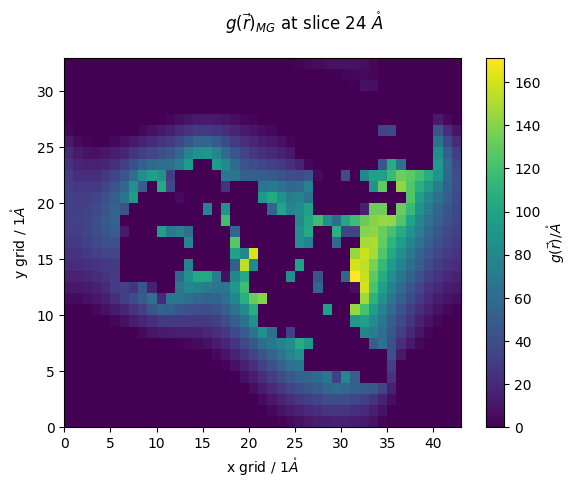

In [40]:
z_slice = 24 # @param {type:"slider", min:1, max:91, step:1}
fig,ax = plt.subplots()
#z_slice = 10
p = ax.pcolormesh(g_r[:,:,z_slice])
ax.set_ylabel(f'y grid / {pdb.resolution}$\\mathring{{A}}$')
ax.set_xlabel(f'x grid / {pdb.resolution}$\\mathring{{A}}$')
#ax.set_ylim(20,100)
#ax.set_xlim(10,65)
fig.colorbar(p,ax=ax, label="$g(\\vec{r})/\\mathring{{A}}$")
fig.suptitle(f'$g(\\vec{{r}})_{{MG}}$ at slice {z_slice*pdb.resolution} $\\mathring{{A}}$')

* Now lets place ions on our grid
* "number_mg_to_place = 5" - we chose to place 5 Mg2+ surronding RNA. You can choose this value per your understand of your system.

In [41]:
number_mg_to_place = 5
placed_waters = pdb.placement(number_mg_to_place,atom_to_select='mg',write_pdb=True,outname=f'placed_mg_{PDB_ID}')#,filename='guv_diis_increase_pdb.txt',write_pdb=True,outname='placed_mg')

In [42]:
number_mg_to_place = 5
placed_waters = pdb.placement(number_mg_to_place,atom_to_select='mg',write_pdb=True,
                              outname=f'placed_mg_{PDB_ID}')#,filename='guv_diis_increase_pdb.txt',write_pdb=True,outname='placed_mg')

In [43]:
#@markdown Here we merge our two PDBs and write them to merged_pdb.pdb
%%capture
u1 = md.Universe(f'fixed_{PDB_ID}.gro')
u2 = md.Universe(f'placed_mg_{PDB_ID}.pdb')
#u2.dimensions = [il6.grid[0],il6.grid[1],il6.grid[2],90,90,90]
md.Merge(u1.atoms,u2.atoms).atoms.write(f'merged_pdb_{PDB_ID}.pdb')

In [44]:
#@markdown View our placed Magnesium
#md.Universe("aligned_merged_pdb.pdb").select_atoms("resname HOH").atoms.write('aligned_waters.pdb')
#md.Universe(f"{PDB_ID}.pdb").select_atoms("resname HOH").atoms.write('orig_waters.pdb')

disp = py3Dmol.view()
disp.addModel(open(f'fixed_{PDB_ID}.pdb','r').read(),'pdb')
#disp.addModel(open('aligned_merged_pdb.pdb','r').read(),'pdb')
disp.setStyle({'model': -1}, {'cartoon': {'color':'grey'}})

#disp.addModel(open('aligned_waters.pdb', 'r').read(),'pdb')
disp.addModel(open(f'placed_mg_{PDB_ID}.pdb', 'r').read(),'pdb',)
#disp.setStyle({'model': -1}, {'sphere': {}})
disp.setStyle({'model': -1}, {'sphere': {'color':'purple'}})
#disp.addModel(open('orig_waters.pdb', 'r').read(),'pdb')
#disp.setStyle({'model': -1}, {'sphere': {'color':'red'}})
#disp.addUnitCell()
#disp.addLabel('Cyan: RISM , Red: True')#,"bottomCenter")#{'alignment':"bottomCenter"},{'fontColor':'cyan'})#:{'color':'cyan'}})#,{'color':'red'})
disp.setHoverable({},True,'''function(atom,viewer,event,container) {
                   if(!atom.label) {
                    atom.label = viewer.addLabel(atom.resn+":"+atom.atom,{position: atom, backgroundColor: 'mintcream', fontColor:'black'});
                   }}''',
               '''function(atom,viewer) {
                   if(atom.label) {
                    viewer.removeLabel(atom.label);
                    delete atom.label;
                   }
                }''')
disp.zoomTo()

disp.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

* we can see that our placed ions are in close proximity
* Our selection command relies on a greedy picking algorithm, picking the highest peak in the distribution, then moving on to the next
* When placing highly charged solvents, one can imagine how placing a single ion, then moving to the next highest peak could be distruptive of the true behavior of the system, as regions of great distribution may be close to one another

* Instead, we can place an ion, then redo our 3DRISM calcultaion
* This is specifically important for highly-highly charged regions, for example kink-turn regions of RNA


In [45]:
#@markdown Here we will redo a 3DRISM calculation each time we place an Ion

#@markdown $\approx$ 1min per iteration
mg_you_want = 5 #@param
out = []
pdb = epipy(f"fixed_{PDB_ID}.gro",f"{PDB_ID}.top",convert=True)
for mg in range(mg_you_want):
  print(f"Starting round {mg}\n")
  pdb.solvent("mg")
  pdb.report(f"placed_mg_{mg}_{PDB_ID}")
  #pdb.rism(resolution=0.5)
  pdb.rism(step=10000,resolution=1)
  pdb.closure = "KGK"
  pdb.err_tol = 1e-06 # we will set a higher tolerance than usual
  pdb.kernel(nt=2)
  out.append(pdb.select_grid('guv of atom mg')[z_slice])
  number_mg_to_place = 1 # per loop
  placed_waters = pdb.placement(number_mg_to_place,atom_to_select='mg',write_pdb=True,outname=f'placed_mg_{mg}_{PDB_ID}')#,filename='guv_diis_increase_pdb.txt',write_pdb=True,outname='placed_mg')
  print(f"finished round {mg}\n")
  ## now we are done with the calc
  if mg == 0:
    u1 = md.Universe(f"fixed_{PDB_ID}.gro")
  else:
    u1 = md.Universe(f'merged_pdb_{mg-1}_{PDB_ID}.pdb')
  #
  u2 = md.Universe(f'placed_mg_{mg}_{PDB_ID}.pdb') #this is the MG we just placed
  # this wont be needed in epipy update
  # but i wrote my pdb atomnames one column too far
  u2.add_TopologyAttr('resnames',['Mg'])
  u2.add_TopologyAttr('elements',['Mg'])
  u2.add_TopologyAttr('names',['Mg'])
  u2.add_TopologyAttr('resid',[mg])
  # merge the two files
  u3 = md.Merge(u1.atoms,u2.atoms)
  # we have to reset the dimensions
  u3.dimensions = [box_x,box_y,box_z,90,90,90]
  # write out
  u3.atoms.write(f'merged_pdb_{mg}_{PDB_ID}.pdb')
  u3.atoms.write(f'merged_pdb_{mg}_{PDB_ID}.gro')
  n_mg = len(u3.select_atoms("name Mg")) # get number of MG as failsafe
  print(f"Merged the PDB and placed ion\nnow contains {n_mg} MG ions\n")
  # now make a new topology
  fixer = app.PDBFile(f'merged_pdb_{mg}_{PDB_ID}.pdb')
  forcefield = app.ForceField('amber14-all.xml','amber14/tip3pfb.xml')#charmm36.xml')
  system = forcefield.createSystem(fixer.topology)
  # print the topology via RDKit
  struct = chem.openmm.load_topology(fixer.topology,system)
  struct.positions = fixer.positions
  struct.save(f'{PDB_ID}_{mg}.top',overwrite=True)
  # Read into epipy
  pdb = epipy(f'merged_pdb_{mg}_{PDB_ID}.gro',f"{PDB_ID}_{mg}.top",convert=True)


converted 7EFH.top to 7EFH.solute
Starting round 0

Calculation finished in 870 steps 
err_tol: 1e-06 actual: 9.9199e-07 
finished round 0

Merged the PDB and placed ion
now contains 1 MG ions

converted 7EFH_0.top to 7EFH_0.solute
Starting round 1

Calculation finished in 904 steps 
err_tol: 1e-06 actual: 9.8827e-07 
finished round 1

Merged the PDB and placed ion
now contains 2 MG ions

converted 7EFH_1.top to 7EFH_1.solute
Starting round 2

Calculation finished in 851 steps 
err_tol: 1e-06 actual: 9.96661e-07 
finished round 2

Merged the PDB and placed ion
now contains 3 MG ions

converted 7EFH_2.top to 7EFH_2.solute
Starting round 3

Calculation finished in 948 steps 
err_tol: 1e-06 actual: 9.93306e-07 
finished round 3

Merged the PDB and placed ion
now contains 4 MG ions

converted 7EFH_3.top to 7EFH_3.solute
Starting round 4

Calculation finished in 774 steps 
err_tol: 1e-06 actual: 9.90788e-07 
finished round 4

Merged the PDB and placed ion
now contains 5 MG ions

converted 7

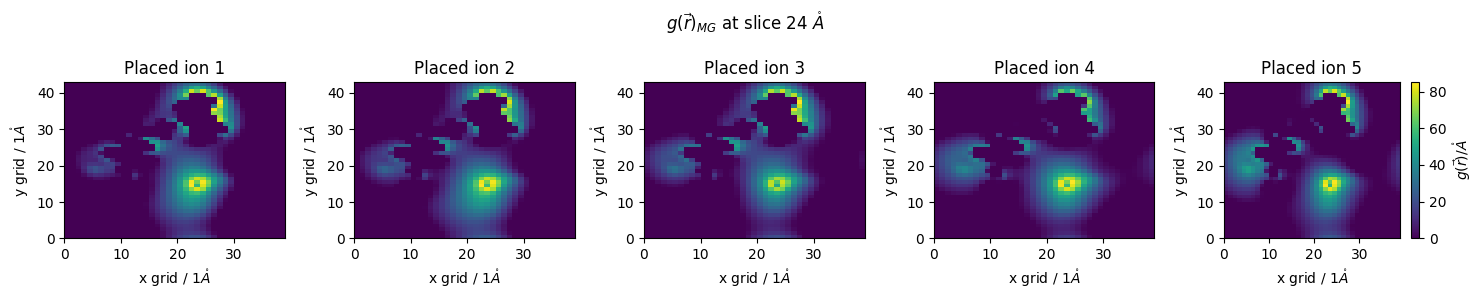

In [46]:
#@markdown lets plot the density difference between iterations
fig,axs = plt.subplots(1,mg_you_want,figsize=(15,3))
#z_slice = 10
for idx,(out_i,ax) in enumerate(zip(out,axs.flatten())):
  #p = ax.pcolormesh(g_r[:,:,z_slice])
  p = ax.pcolormesh(out_i)
  ax.set_ylabel(f'y grid / {pdb.resolution}$\\mathring{{A}}$')
  ax.set_xlabel(f'x grid / {pdb.resolution}$\\mathring{{A}}$')
  ax.set_title(f"Placed ion {idx+1}")
  #ax.set_ylim(20,100)
  #ax.set_xlim(10,65)
fig.colorbar(p,ax=ax, label="$g(\\vec{r})/\\mathring{{A}}$")
fig.suptitle(f'$g(\\vec{{r}})_{{MG}}$ at slice {z_slice*pdb.resolution} $\\mathring{{A}}$')
fig.tight_layout()

In [47]:
#@markdown Now lets view the 'properly placed' Ions
u = md.Universe(f'merged_pdb_{mg}_{PDB_ID}.pdb')
u.select_atoms("name Mg").write("total_mg_placed.pdb")

disp = py3Dmol.view()
disp.addModel(open(f'merged_pdb_{mg}_{PDB_ID}.pdb','r').read(),'pdb')
#disp.addModel(open('aligned_merged_pdb.pdb','r').read(),'pdb')
disp.setStyle({'model': -1}, {'stick': {}})
##################
disp.addModel(open('total_mg_placed.pdb','r').read(),'pdb')
disp.setStyle({'model': -1}, {'sphere': {'color':'purple'}})
#disp.addModel(open('orig_waters.pdb', 'r').read(),'pdb')
#disp.setStyle({'model': -1}, {'sphere': {'color':'red'}})
#disp.addUnitCell()
#disp.addLabel('Cyan: RISM , Red: True')#,"bottomCenter")#{'alignment':"bottomCenter"},{'fontColor':'cyan'})#:{'color':'cyan'}})#,{'color':'red'})
disp.setHoverable({},True,'''function(atom,viewer,event,container) {
                   if(!atom.label) {
                    atom.label = viewer.addLabel(atom.resn+":"+atom.atom,{position: atom, backgroundColor: 'mintcream', fontColor:'black'});
                   }}''',
               '''function(atom,viewer) {
                   if(atom.label) {
                    viewer.removeLabel(atom.label);
                    delete atom.label;
                   }
                }''')
disp.zoomTo()

disp.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# DONE

We encourage you to play around with this tutorial and substitute your own PDB file  

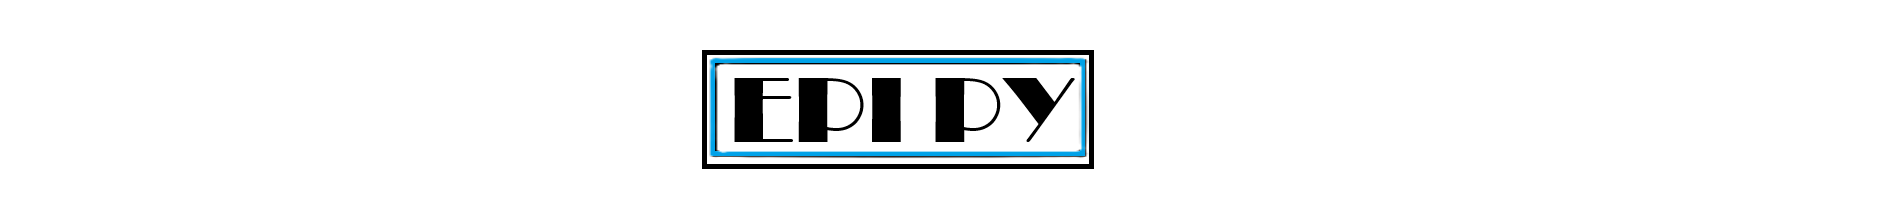